In [58]:
import pandas as pd
import numpy as np

In [59]:
df = pd.read_csv('./table/overall_tab.csv')
df = df.sort_values(by='chapter')

In [60]:
chi_result = pd.read_csv('chi2_results.csv')
chi_result

,Test Name,statistic,P-Value,Result(Alpha=0.05),Description
0,overall_chapter,570072.330587,0.000000e+00,Reject H0,the difference in the distribution of the obse...
1,tab_chapter1,26789.108421,0.000000e+00,Reject H0,the difference in the distribution of the obse...
2,tab_chapter2,11019.766350,0.000000e+00,Reject H0,the difference in the distribution of the obse...
3,tab_chapter3,14144.621625,0.000000e+00,Reject H0,the difference in the distribution of the obse...
4,tab_chapter4,101539.618777,0.000000e+00,Reject H0,the difference in the distribution of the obse...
5,tab_chapter5,62211.904463,0.000000e+00,Reject H0,the difference in the distribution of the obse...
6,tab_chapter6,32887.807794,0.000000e+00,Reject H0,the difference in the distribution of the obse...
7,tab_chapter7,14303.288138,0.000000e+00,Reject H0,the difference in the distribution of the obse...
8,tab_chapter8,4975.338873,0.000000e+00,Reject H0,the difference in the distribution of the obse...
9,tab_chapter9,103018.384431,0.000000e+00,Reject H0,the difference in the distribution of the obse...


In [61]:
df2 = df.copy()

In [62]:
def absolute_percentage_difference_by_sum_each_group(ed_count, ipd_count): #สูตรหารตามกลุ่ม
    """Calculate the absolute percentage difference between ED and IPD."""
    if (ed_count + ipd_count) == 0:
        return np.nan  # Avoid division by zero
    ed_percentage = (ed_count / df['ED'].sum()) * 100
    ipd_percentage = (ipd_count / df['IPD'].sum()) * 100
    return abs(ed_percentage - ipd_percentage), ed_percentage, ipd_percentage

def absolute_percentage_difference_by_sum_total(ed_count, ipd_count): # สูตรหารด้วย total รวม
    """Calculate the absolute percentage difference between ED and IPD."""
    if (ed_count + ipd_count) == 0:
        return np.nan  # Avoid division by zero
    ed_percentage = (ed_count / (ed_count + ipd_count)) * 100
    ipd_percentage = (ipd_count / (ed_count + ipd_count)) * 100
    return abs(ed_percentage - ipd_percentage), ed_percentage, ipd_percentage

def risk_ratio(ed_percentage, ipd_percentage):
    """Calculate risk ratio using ED and IPD percentages."""
    return ed_percentage / ipd_percentage if ipd_percentage != 0 else np.nan

# Assuming df is a DataFrame with columns "ED" and "IPD"
df[["percentage_difference", "ed_percentage", "ipd_percentage"]] = df.apply(
    lambda row: absolute_percentage_difference_by_sum_each_group(row["ED"], row["IPD"]), axis=1, result_type="expand"
)

df["risk_ratio"] = df.apply(
    lambda row: risk_ratio(row["ed_percentage"], row["ipd_percentage"]), axis=1
)

df2[["percentage_difference", "ed_percentage", "ipd_percentage"]] = df2.apply(
    lambda row: absolute_percentage_difference_by_sum_total(row["ED"], row["IPD"]), axis=1, result_type="expand"
)

df2["risk_ratio"] = df2.apply(
    lambda row: risk_ratio(row["ed_percentage"], row["ipd_percentage"]), axis=1
)

In [63]:
# df ใช้สูตรหารด้วย total แต่ละแผนก
# df2 ใช้สูตรหารด้วย total รวม 2 แผนก

In [ ]:
df.sort_values(by='risk_ratio',ascending=False)  
# Chapter 18, 19 ,20 มีแนวโน้มจะอยู่ที่ ED 
# Chapter 17, 3, 21 มีแนวโน้มจะอยู่ที่ IPD

,chapter,ED,IPD,percentage_difference,ed_percentage,ipd_percentage,risk_ratio
0,18,252201,370060,18.967371,26.841487,7.874116,3.408825
1,19,98659,151677,7.272799,10.500173,3.227375,3.253472
3,20,84982,162558,5.585645,9.044545,3.458900,2.614861
18,8,2962,8284,0.138976,0.315243,0.176266,1.788443
11,12,18380,61208,0.653784,1.956164,1.302380,1.501991
5,13,56951,191518,1.986126,6.061235,4.075109,1.487380
10,10,34869,180230,0.123853,3.711071,3.834924,0.967704
17,7,5414,30793,0.079005,0.576206,0.655212,0.879420
9,14,39200,227362,0.665781,4.172015,4.837796,0.862379
20,16,9,59,0.000298,0.000958,0.001255,0.762993


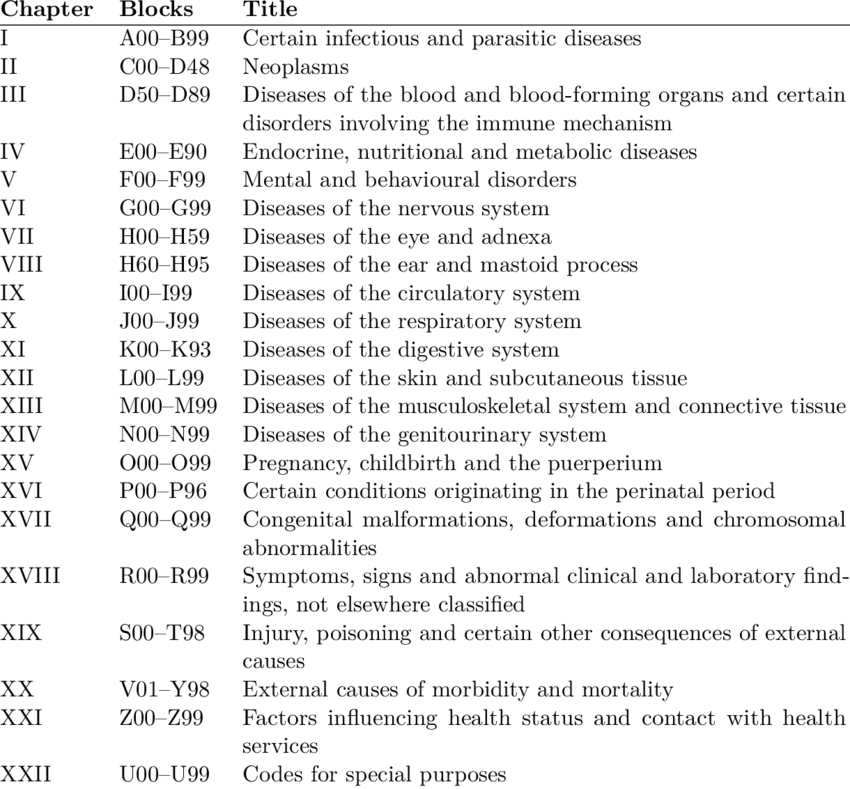

In [65]:
df2.sort_values(by='risk_ratio',ascending=False)

,chapter,ED,IPD,percentage_difference,ed_percentage,ipd_percentage,risk_ratio
0,18,252201,370060,18.940445,40.529778,59.470222,0.681514
1,19,98659,151677,21.178736,39.410632,60.589368,0.650455
3,20,84982,162558,31.338774,34.330613,65.669387,0.522780
18,8,2962,8284,47.323493,26.338254,73.661746,0.357557
11,12,18380,61208,53.812132,23.093934,76.906066,0.300288
5,13,56951,191518,54.158466,22.920767,77.079233,0.297366
10,10,34869,180230,67.578650,16.210675,83.789325,0.193469
17,7,5414,30793,70.094181,14.952910,85.047090,0.175819
9,14,39200,227362,70.588456,14.705772,85.294228,0.172412
20,16,9,59,73.529412,13.235294,86.764706,0.152542


### การตีความผลลัพธ์
หมวดที่มี percentage_difference สูง เช่น 35% อาจ Pratical Significance เนื่องจากสัดส่วนของ IPD สูงกว่ามาก

การตีความค่า RR\
RR > 1 → บ่งบอกว่าผู้ป่วยในหมวดนี้มีแนวโน้มไปรักษาที่ ED มากกว่าที่ IPD\
RR < 1 → บ่งบอกว่าผู้ป่วยในหมวดนี้มีแนวโน้มเข้ารับการรักษาที่ IPD มากกว่า ED\
RR ≈ 1 → ไม่มีความแตกต่างในเชิงปฏิบัติ